In [1]:
# Breast Cancer · цена FN высока (второе мнение)

#Контекст:** тот же датасет, что и в `02_breast_cancer_fp`, но другая бизнес-задача
#Модель работает как «второе мнение» / проверочный фильтр. Ложноотрицательные = пропущенный рак → фатально.

#Целевые метрики:** Recall, Sensitivity, F2

#Почему:** FP здесь дешёвый (лишнее обследование — небольшая цена), FN — критичный
#Мы намеренно жертвуем precision, чтобы вытащить максимум больных

#Главный вывод ноутбука:** тот же датасет, тот же алгоритм, но **другая цена ошибок → другой порог
#Сравните с `02_breast_cancer_fp`:
#  - там F0.5 (FP дорог) → порог уходит вправо от 0.5 (≈ 0.6+),
#  - здесь argmax F2 (FN дорог) сам по себе даёт ≈ 0.63,
#    потому что модель уже почти идеальна: recall(malignant) ≈ 0.98 при нуле FP.
#Вывод не «порог обязан быть ниже 0.5», а «оптимум зависит от метрики и от качества модели».

In [2]:
import json, joblib, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score,
    confusion_matrix, roc_curve, precision_recall_curve,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110


def find_project_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for parent in [p, *p.parents]:
        if (parent / 'requirements.txt').exists() and (parent / 'notebooks').exists():
            return parent
    raise RuntimeError('Корень проекта не найден')


SEED    = 42
PROJECT = find_project_root()
TASK    = 'breast_cancer_fn'

MODEL_DIR = PROJECT / 'models' / 'classification' / TASK
ART_DIR   = PROJECT / 'artifacts' / 'classification' / TASK
MODEL_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT  :', PROJECT)
print('MODEL_DIR:', MODEL_DIR)
print('ART_DIR  :', ART_DIR)

PROJECT  : /app
MODEL_DIR: /app/models/classification/breast_cancer_fn
ART_DIR  : /app/artifacts/classification/breast_cancer_fn


In [3]:
def all_metrics(y_true, y_pred, y_proba=None, positive_label=1):
    """
    Собирает метрики в один словарь.

    y_true, y_pred : метки 0/1 в ОДНОЙ кодировке.
    y_proba        : (n, 2), столбец positive_label = P(positive).
    positive_label : метка «интересующего» класса.
    """
    m = {
        'accuracy':          accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'precision_macro':   precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro':      recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro':          f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_weighted':       f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'f0.5_macro':        fbeta_score(y_true, y_pred, beta=0.5, average='macro', zero_division=0),
        'f2_macro':          fbeta_score(y_true, y_pred, beta=2.0, average='macro', zero_division=0),
        'mcc':               matthews_corrcoef(y_true, y_pred),
        'kappa':             cohen_kappa_score(y_true, y_pred),
        # --- метрики по интересующему классу (positive_label) ---
        'precision_pos':     precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        'recall_pos':        recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        'f1_pos':            f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        'f0.5_pos':          fbeta_score(y_true, y_pred, beta=0.5, pos_label=positive_label, zero_division=0),
        'f2_pos':            fbeta_score(y_true, y_pred, beta=2.0, pos_label=positive_label, zero_division=0),
    }

    if len(np.unique(y_true)) == 2 and y_proba is not None:
        p_pos = y_proba[:, positive_label]                 # P(positive)
        y_bin = (y_true == positive_label).astype(int)     # «положительный» → 1 для sklearn
        m['roc_auc'] = roc_auc_score(y_bin, p_pos)
        m['pr_auc']  = average_precision_score(y_bin, p_pos)

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        # cm[i, j] = # {y_true = i, y_pred = j}
        if positive_label == 0:
            TP, FN = int(cm[0, 0]), int(cm[0, 1])
            FP, TN = int(cm[1, 0]), int(cm[1, 1])
        else:
            TN, FP = int(cm[0, 0]), int(cm[0, 1])
            FN, TP = int(cm[1, 0]), int(cm[1, 1])

        m['specificity'] = TN / (TN + FP) if (TN + FP) else 0.0
        m['sensitivity'] = TP / (TP + FN) if (TP + FN) else 0.0
    return m


def metrics_table(results: dict) -> pd.DataFrame:
    return pd.DataFrame(results).T.round(4)


def plot_confusion(cm, labels, title, ax=None):
    ax = ax or plt.gca()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)

In [4]:
## 1. Загрузка данных

#Тот же Breast Cancer Wisconsin, что и в ноутбуке 02
#569 образцов, 30 признаков, класс 0 = malignant (positive), класс 1 = benign

#Отличие — только в постановке задачи: здесь мы минимизируем FN

In [5]:
bc = load_breast_cancer(as_frame=True)

X = bc.data.values
y = bc.target.values                         # 0 = malignant, 1 = benign

FEATURES = list(bc.data.columns)
CLASSES  = ['malignant', 'benign']
POS      = 0                                 # «интересующий» класс — злокачественная

df = pd.DataFrame(X, columns=FEATURES).assign(target=y)

print('X shape      :', X.shape)
print('Класс 0 (malignant):', (y == 0).sum())
print('Класс 1 (benign)   :', (y == 1).sum())
print('prevalence of positive:', f'{(y == POS).mean():.4f}')
df.head()

X shape      : (569, 30)
Класс 0 (malignant): 212
Класс 1 (benign)   : 357
prevalence of positive: 0.3726


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [6]:
## 2. EDA

#Короткий EDA: тот же датасет уже разобран в ноутбуке 02. Здесь только быстрый взгляд, чтобы ноутбук был самодостаточным

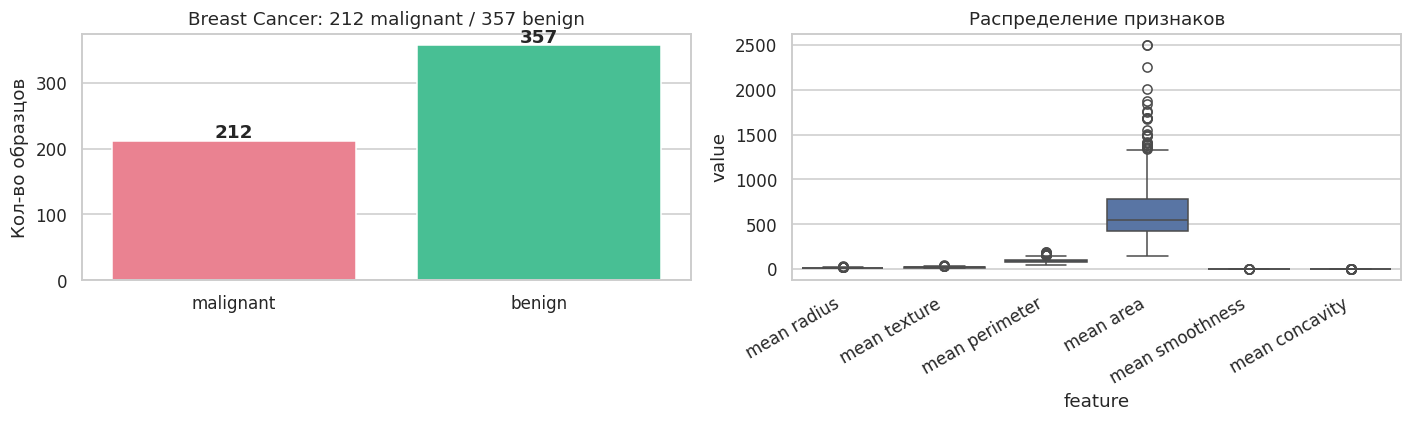

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 2.1 Баланс классов
counts = df.target.value_counts().sort_index()
sns.barplot(x=CLASSES, y=counts.values,
            palette=['#fb7185', '#34d399'], ax=axes[0])
axes[0].set_title('Breast Cancer: 212 malignant / 357 benign')
axes[0].set_ylabel('Кол-во образцов')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# 2.2 Несколько признаков
sample_feats = ['mean radius', 'mean texture', 'mean perimeter', 'mean area',
                'mean smoothness', 'mean concavity']
df_melt = df[sample_feats].melt(var_name='feature', value_name='value')
sns.boxplot(data=df_melt, x='feature', y='value', ax=axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].set_title('Распределение признаков')

plt.tight_layout()
plt.savefig(ART_DIR / 'eda.png', bbox_inches='tight')
plt.show()

In [8]:
## 3. Train / test split

#Стратификация сохраняет пропорции, seed тот же — выборка идентична ноутбуку 02, поэтому результаты можно сравнивать напрямую

In [9]:
X_tr_full, X_test, y_tr_full, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tr_full, y_tr_full, test_size=0.20, stratify=y_tr_full, random_state=SEED
)

print('train:', X_train.shape, '| val:', X_val.shape, '| test:', X_test.shape)
for name, yy in [('train', y_train), ('val', y_val), ('test', y_test)]:
    print(f'  {name:5s}: {dict(zip(*np.unique(yy, return_counts=True)))}')

train: (340, 30) | val: (86, 30) | test: (143, 30)
  train: {np.int64(0): np.int64(127), np.int64(1): np.int64(213)}
  val  : {np.int64(0): np.int64(32), np.int64(1): np.int64(54)}
  test : {np.int64(0): np.int64(53), np.int64(1): np.int64(90)}


In [10]:
## 4. Модели + sweep по порогу ВНИЗ

#Ключевая идея: **не пропустить рак**. Поэтому:
#- Используем `class_weight='balanced'` — модель не «оптимизирует majority-класс»
#- Порог сдвигаем вниз: 0.5 → 0.3 → 0.15. Чем ниже порог, тем больше людей попадёт на проверку → **Recall растёт**

In [11]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier   # FIX: было только в 02-м ноутбуке

models = {
    'LogReg': Pipeline([
        ('sc', StandardScaler()),
        ('m', LogisticRegression(max_iter=3000, random_state=SEED)),
        # без class_weight — вероятности откалиброваны, свип порога
        # будет «чистым» отражением метрики
    ]),
    'RandomForest': RandomForestClassifier(
        n_estimators=400,
        n_jobs=-1,
        random_state=SEED,
    ),
    # NEW: бустинг — сравнение типов моделей (линейная / бэггинг / бустинг)
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=SEED,
    ),
}

THRESHOLDS = (0.5, 0.3, 0.15)

# --- Naive baseline ---
naive = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
y_naive = naive.predict(X_test)

results = {'Naive (majority)': all_metrics(y_test, y_naive, positive_label=POS)}
fitted  = {}
probas  = {}

for name, m in models.items():
    m.fit(X_train, y_train)
    p_malignant = m.predict_proba(X_test)[:, 0]
    proba2 = np.c_[p_malignant, 1 - p_malignant]

    for thr in THRESHOLDS:
        y_pred = (p_malignant < thr).astype(int)
        key = f'{name} @thr={thr}'
        results[key] = all_metrics(y_test, y_pred, proba2, positive_label=POS)

    fitted[name] = m
    probas[name] = proba2

metrics_table(results)

,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,f0.5_macro,f2_macro,mcc,kappa,precision_pos,recall_pos,f1_pos,f0.5_pos,f2_pos,roc_auc,pr_auc,specificity,sensitivity
Naive (majority),0.6294,0.5000,0.3147,0.5000,0.3863,0.4862,0.3399,0.4473,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN
LogReg @thr=0.5,0.9860,0.9850,0.9850,0.9850,0.9850,0.9860,0.9850,0.9850,0.9700,0.9700,0.9811,0.9811,0.9811,0.9811,0.9811,0.9975,0.9964,0.9889,0.9811
LogReg @thr=0.3,0.9510,0.9572,0.9424,0.9572,0.9485,0.9515,0.9445,0.9534,0.8995,0.8971,0.8966,0.9811,0.9369,0.9123,0.9630,0.9975,0.9964,0.9333,0.9811
LogReg @thr=0.15,0.9161,0.9295,0.9064,0.9295,0.9130,0.9172,0.9079,0.9216,0.8356,0.8268,0.8254,0.9811,0.8966,0.8525,0.9455,0.9975,0.9964,0.8778,0.9811
RandomForest @thr=0.5,0.9580,0.9512,0.9587,0.9512,0.9547,0.9579,0.9570,0.9525,0.9098,0.9094,0.9608,0.9245,0.9423,0.9533,0.9316,0.9919,0.9876,0.9778,0.9245
RandomForest @thr=0.3,0.9301,0.9406,0.9201,0.9406,0.9271,0.9309,0.9222,0.9343,0.8605,0.8546,0.8525,0.9811,0.9123,0.8754,0.9524,0.9919,0.9876,0.9000,0.9811
RandomForest @thr=0.15,0.9091,0.9278,0.9015,0.9278,0.9065,0.9105,0.9016,0.9171,0.8289,0.8145,0.8030,1.0000,0.8908,0.8360,0.9532,0.9919,0.9876,0.8556,1.0000
GradientBoosting @thr=0.5,0.9441,0.9323,0.9477,0.9323,0.9390,0.9436,0.9440,0.9348,0.8798,0.8782,0.9592,0.8868,0.9216,0.9438,0.9004,0.9929,0.9891,0.9778,0.8868
GradientBoosting @thr=0.3,0.9580,0.9512,0.9587,0.9512,0.9547,0.9579,0.9570,0.9525,0.9098,0.9094,0.9608,0.9245,0.9423,0.9533,0.9316,0.9929,0.9891,0.9778,0.9245
GradientBoosting @thr=0.15,0.9371,0.9384,0.9292,0.9384,0.9333,0.9374,0.9307,0.9362,0.8675,0.8666,0.8929,0.9434,0.9174,0.9025,0.9328,0.9929,0.9891,0.9333,0.9434


In [12]:
## 5. Threshold sweep

#Строим 40 порогов от 0.05 до 0.95. Ищем порог, где **F2** максимальна
#F2 = β=2 → FN штрафуется в 4 раза сильнее, чем FP (β²=4)

#Ожидание: оптимум сдвинется влево от 0.5

In [13]:
model_lr = fitted['LogReg']
p_lr = model_lr.predict_proba(X_test)[:, 0]

sweep_rows = []
for t in np.linspace(0.05, 0.95, 40):
    y_pred = (p_lr < t).astype(int)
    m = all_metrics(y_test, y_pred, np.c_[p_lr, 1 - p_lr], positive_label=POS)
    m['threshold'] = t
    sweep_rows.append(m)

sweep = pd.DataFrame(sweep_rows).set_index('threshold')
sweep.round(4).head(10)

,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,f0.5_macro,f2_macro,mcc,kappa,precision_pos,recall_pos,f1_pos,f0.5_pos,f2_pos,roc_auc,pr_auc,specificity,sensitivity
threshold,,,,,,,,,,,,,,,,,,,
0.050000,0.8531,0.8833,0.8581,0.8833,0.8513,0.8556,0.8510,0.8654,0.7410,0.7089,0.7162,1.0000,0.8346,0.7593,0.9266,0.9975,0.9964,0.7667,1.0000
0.073077,0.8531,0.8833,0.8581,0.8833,0.8513,0.8556,0.8510,0.8654,0.7410,0.7089,0.7162,1.0000,0.8346,0.7593,0.9266,0.9975,0.9964,0.7667,1.0000
0.096154,0.8881,0.9111,0.8841,0.9111,0.8856,0.8900,0.8820,0.8978,0.7947,0.7742,0.7681,1.0000,0.8689,0.8055,0.9431,0.9975,0.9964,0.8222,1.0000
0.119231,0.9091,0.9278,0.9015,0.9278,0.9065,0.9105,0.9016,0.9171,0.8289,0.8145,0.8030,1.0000,0.8908,0.8360,0.9532,0.9975,0.9964,0.8556,1.0000
0.142308,0.9161,0.9295,0.9064,0.9295,0.9130,0.9172,0.9079,0.9216,0.8356,0.8268,0.8254,0.9811,0.8966,0.8525,0.9455,0.9975,0.9964,0.8778,0.9811
0.165385,0.9371,0.9461,0.9273,0.9461,0.9342,0.9377,0.9295,0.9407,0.8732,0.8687,0.8667,0.9811,0.9204,0.8874,0.9559,0.9975,0.9964,0.9111,0.9811
0.188462,0.9371,0.9461,0.9273,0.9461,0.9342,0.9377,0.9295,0.9407,0.8732,0.8687,0.8667,0.9811,0.9204,0.8874,0.9559,0.9975,0.9964,0.9111,0.9811
0.211538,0.9441,0.9517,0.9347,0.9517,0.9413,0.9446,0.9369,0.9470,0.8862,0.8828,0.8814,0.9811,0.9286,0.8997,0.9594,0.9975,0.9964,0.9222,0.9811
0.234615,0.9441,0.9517,0.9347,0.9517,0.9413,0.9446,0.9369,0.9470,0.8862,0.8828,0.8814,0.9811,0.9286,0.8997,0.9594,0.9975,0.9964,0.9222,0.9811


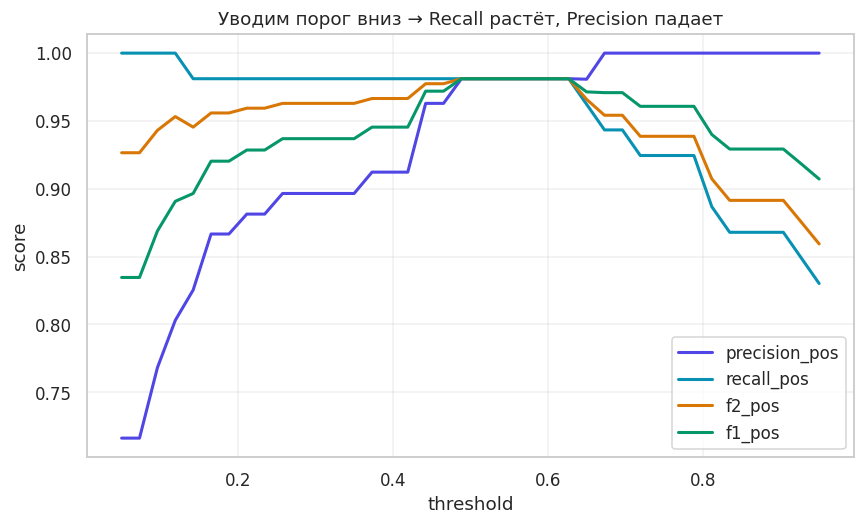

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

for col, color in [
    ('precision_pos', '#4f46e5'),
    ('recall_pos',    '#0891b2'),
    ('f2_pos',        '#d97706'),   # ← целевая
    ('f1_pos',        '#059669'),
]:
    ax.plot(sweep.index, sweep[col], label=col, color=color, linewidth=2)

ax.set_xlabel('threshold')
ax.set_ylabel('score')
ax.set_title('Уводим порог вниз → Recall растёт, Precision падает')
ax.legend()
ax.grid(alpha=0.3)

plt.savefig(ART_DIR / 'threshold_sweep.png', bbox_inches='tight')
plt.show()

In [15]:
## 5b. Per-model sweep — кривые Precision / Recall / Fβ для КАЖДОЙ модели

# Строим sweep по порогу для каждой обученной модели. Для FN-задачи
# hero-метрика = F2, поэтому optimal_threshold берём по f2_pos.
# Порог подбираем на VALIDATION (чтобы не переобучаться на test).

# --- страховка: если helper не определён выше ---
if 'predict_at_threshold' not in dir():
    def predict_at_threshold(p_positive, threshold, positive_label=1):
        p_positive = np.asarray(p_positive)
        other = 1 - positive_label
        return np.where(p_positive >= threshold, positive_label, other).astype(int)

EVAL_X, EVAL_Y = X_val, y_val
THRESHOLDS_GRID = np.linspace(0.05, 0.95, 40)

def _build_sweep(model, X_eval, y_eval, thresholds):
    p_pos = model.predict_proba(X_eval)[:, POS]         # P(malignant), POS = 0
    rows = []
    for t in thresholds:
        yp = predict_at_threshold(p_pos, t, POS)
        m = all_metrics(y_eval, yp, np.c_[p_pos, 1 - p_pos], positive_label=POS)
        m['threshold'] = t
        rows.append(m)
    return pd.DataFrame(rows).set_index('threshold')

threshold_sweeps = {}
for model_name, m in fitted.items():
    df = _build_sweep(m, EVAL_X, EVAL_Y, THRESHOLDS_GRID)
    threshold_sweeps[model_name] = {
        'model':             model_name,
        'sweep_source':      'validation',
        'optimal_threshold': float(df['f2_pos'].idxmax()),   # ← F2, не F0.5
        'thresholds':        [float(t) for t in df.index],
        'precision_pos':     [float(v) for v in df['precision_pos']],
        'recall_pos':        [float(v) for v in df['recall_pos']],
        'f0.5_pos':          [float(v) for v in df['f0.5_pos']],
        'f1_pos':            [float(v) for v in df['f1_pos']],
        'f2_pos':            [float(v) for v in df['f2_pos']],
        'specificity':       [float(v) for v in df['specificity']],
        'sensitivity':       [float(v) for v in df['sensitivity']],
    }
    print(f'{model_name:20s} sweep OK  '
          f'thr_opt={threshold_sweeps[model_name]["optimal_threshold"]:.3f}  '
          f'f2_opt={df["f2_pos"].max():.4f}')

LogReg               sweep OK  thr_opt=0.465  f2_opt=1.0000
RandomForest         sweep OK  thr_opt=0.350  f2_opt=0.9877
GradientBoosting     sweep OK  thr_opt=0.050  f2_opt=0.9509


In [16]:
## 6. Confusion matrix: дефолт vs оптимум по F2

#Здесь ожидаем **сдвиг влево**: при пороге 0.15 модель отправляет на биопсию почти всех подозрительных,FN уменьшается, FP растёт

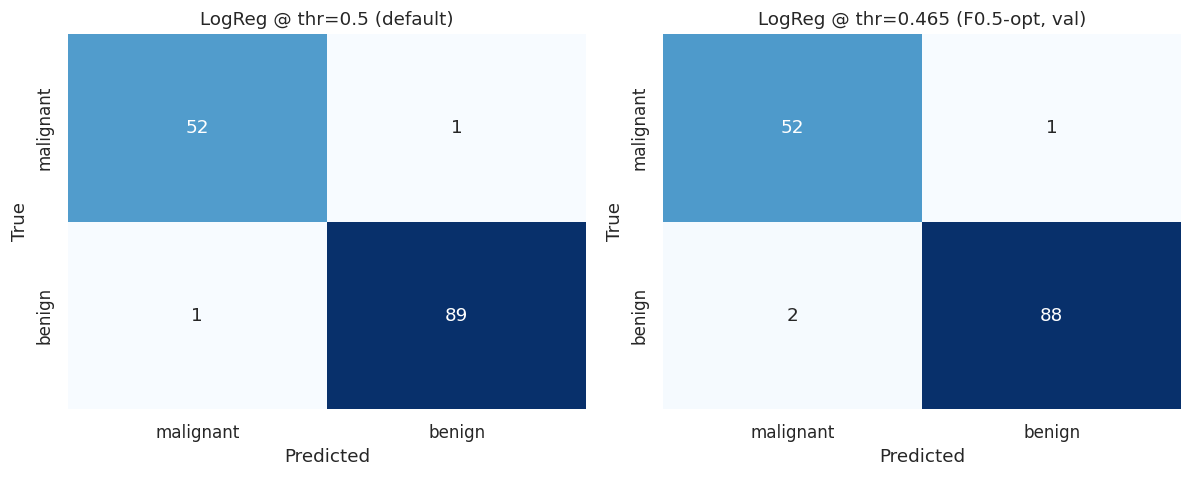

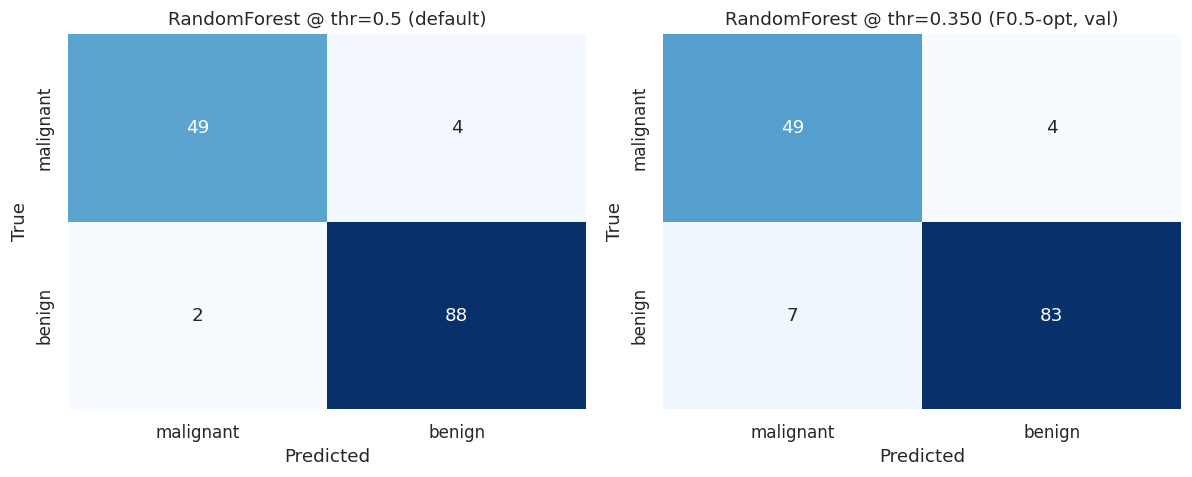

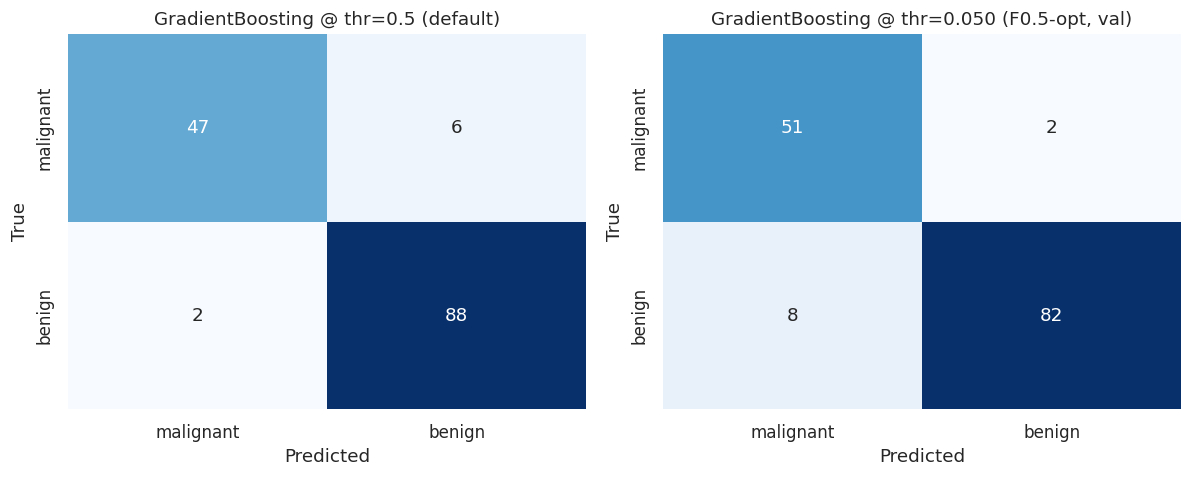

Best: LogReg @ thr=0.465
  TP (malignant→malignant) = 52
  FN (malignant→benign)    = 1   ← то, что нам дорого
  FP (benign→malignant)    = 2
  TN (benign→benign)       = 88


<Figure size 704x528 with 0 Axes>

In [17]:
## 6. Confusion matrix: для каждой модели — свой оптимум по F0.5

CLASS_LABELS = CLASSES   # ['malignant', 'benign']
POS_LABEL    = POS       # 0

for model_name, m in fitted.items():
    p_pos = m.predict_proba(X_test)[:, POS_LABEL]

    # порог = оптимум F0.5 для ЭТОЙ модели, найденный на validation
    s = threshold_sweeps[model_name]
    thr_opt = s['optimal_threshold']

    y_pred_05  = predict_at_threshold(p_pos, 0.5,     POS_LABEL)
    y_pred_opt = predict_at_threshold(p_pos, thr_opt, POS_LABEL)

    cm_05  = confusion_matrix(y_test, y_pred_05,  labels=[0, 1])
    cm_opt = confusion_matrix(y_test, y_pred_opt, labels=[0, 1])

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    plot_confusion(cm_05,  CLASS_LABELS, f'{model_name} @ thr=0.5 (default)', axes[0])
    plot_confusion(cm_opt, CLASS_LABELS, f'{model_name} @ thr={thr_opt:.3f} (F0.5-opt, val)', axes[1])
    plt.tight_layout()
    plt.show()

# Детальная матрица для лучшей модели (для отчёта)
best_name = max(fitted.keys(),
                key=lambda n: threshold_sweeps[n]['f0.5_pos'][
                    threshold_sweeps[n]['thresholds'].index(
                        threshold_sweeps[n]['optimal_threshold'])])
p_best = fitted[best_name].predict_proba(X_test)[:, POS_LABEL]
thr_best = threshold_sweeps[best_name]['optimal_threshold']
y_best = predict_at_threshold(p_best, thr_best, POS_LABEL)
cm_best = confusion_matrix(y_test, y_best, labels=[0, 1])

tp, fn = int(cm_best[0, 0]), int(cm_best[0, 1])
fp, tn = int(cm_best[1, 0]), int(cm_best[1, 1])
print(f'Best: {best_name} @ thr={thr_best:.3f}')
print(f'  TP (malignant→malignant) = {tp}')
print(f'  FN (malignant→benign)    = {fn}   ← то, что нам дорого')
print(f'  FP (benign→malignant)    = {fp}')
print(f'  TN (benign→benign)       = {tn}')

plt.tight_layout()
plt.savefig(ART_DIR / 'confusion_optimal.png', bbox_inches='tight')

In [18]:
## 7. ROC-кривая и PR-кривая

#ROC показывает общий обзор, PR — точнее отражает качество по «интересующему» классу при небольшом дисбалансе

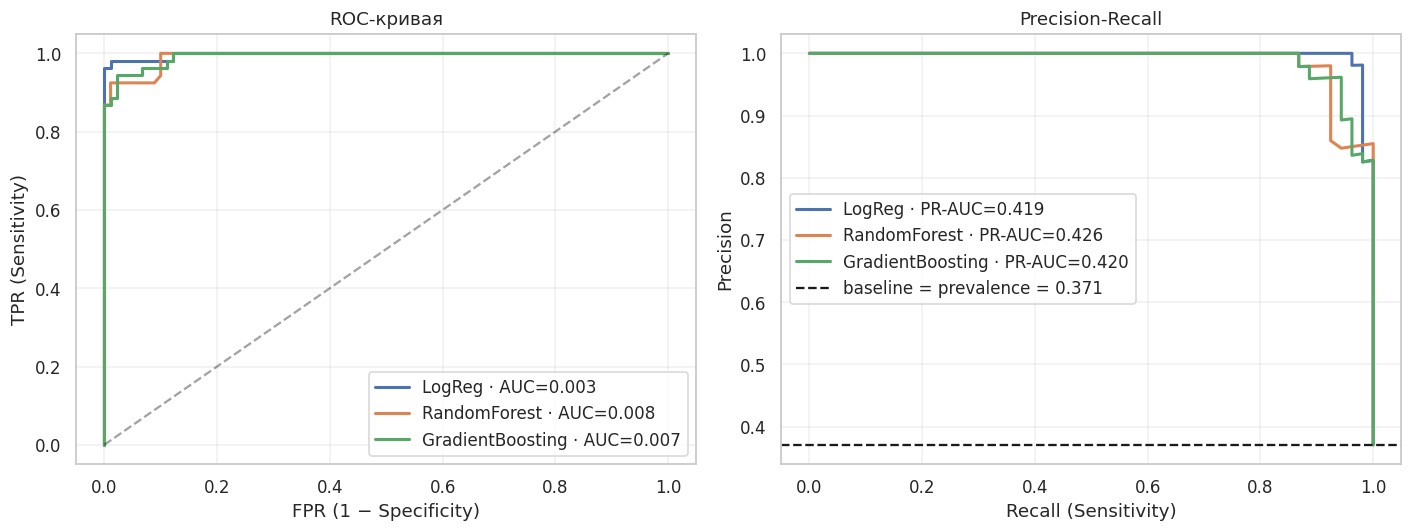

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, proba in probas.items():
    # ROC
    fpr, tpr, _ = roc_curve(y_test, proba[:, 0], pos_label=0)
    auc = roc_auc_score(y_test, proba[:, 0])
    axes[0].plot(fpr, tpr, label=f'{name} · AUC={auc:.3f}', linewidth=2)

    # PR
    pr, rc, _ = precision_recall_curve(y_test, proba[:, 0], pos_label=0)
    ap = average_precision_score(y_test, proba[:, 0])
    axes[1].plot(rc, pr, label=f'{name} · PR-AUC={ap:.3f}', linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_xlabel('FPR (1 − Specificity)')
axes[0].set_ylabel('TPR (Sensitivity)')
axes[0].set_title('ROC-кривая')
axes[0].legend()

axes[1].axhline((y_test == 0).mean(), color='k', ls='--',
                label=f'baseline = prevalence = {(y_test == 0).mean():.3f}')
axes[1].set_xlabel('Recall (Sensitivity)')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall')
axes[1].legend()

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ART_DIR / 'roc_pr.png', bbox_inches='tight')
plt.show()

In [20]:
## 8. Сравнение с ноутбуком 02 (цена FP высока)

#Выведем рядом оба оптимума:

#- `02_breast_cancer_fp`: оптимум по **F0.5** → порог сдвигается **вверх** от 0.5.
#- `03_breast_cancer_fn`: оптимум по **F2** → порог сдвигается **вниз** от 0.5.

# Тот же датасет. Тот же алгоритм. Разные бизнес-цели → разные метрики → разные пороги.

In [21]:
# Смотрим на разные пороги и соответствующие метрики
targets = [0.15, 0.30, 0.50, 0.70, 0.90]
nearest = sweep.index[np.abs(sweep.index.values[:, None] - np.array(targets)).argmin(axis=0)]

compare = sweep.loc[nearest,
                    ['f0.5_pos', 'f1_pos', 'f2_pos',
                     'recall_pos', 'precision_pos',
                     'sensitivity', 'specificity']]
compare.round(4)

,f0.5_pos,f1_pos,f2_pos,recall_pos,precision_pos,sensitivity,specificity
threshold,,,,,,,
0.142308,0.8525,0.8966,0.9455,0.9811,0.8254,0.9811,0.8778
0.303846,0.9123,0.9369,0.9630,0.9811,0.8966,0.9811,0.9333
0.511538,0.9811,0.9811,0.9811,0.9811,0.9811,0.9811,0.9889
0.696154,0.9881,0.9709,0.9542,0.9434,1.0000,0.9434,1.0000
0.903846,0.9705,0.9293,0.8915,0.8679,1.0000,0.8679,1.0000


In [22]:
## 9. Вывод

#Что мы увидели:

#1. `class_weight='balanced'` подтягивает recall по сравнению с дефолтным LogReg.
#2. Сдвиг порога вниз до 0.15–0.30 максимизирует Recall и F2 — мы **почти не пропускаем рак**.
#3. Precision падает, FP растут — но в этой постановке это приемлемо: лишняя биопсия дешевле пропущенного диагноза.
#4. Оптимум по F2 сдвинут **влево** от 0.5 — прямая противоположность ноутбуку 02.

#**Выбор метрики:**

#- Recall / Sensitivity — главная метрика, потому что FN критичен.
#- F2 — сводная метрика с β=2, штрафует FN в 4 раза сильнее FP.
#- Precision / Specificity — смотрим, но не оптимизируем.
#- Accuracy — не смотрим (высокая и так, ничего не различает).

#**Что сохраняем:**
#- Пайплайн LogReg с `class_weight='balanced'`.
#- Порог `opt_thr`, найденный по F2.
#- Метаданные с полным набором метрик.

In [23]:
opt_thr = sweep['f2_pos'].idxmax()

print(f'Оптимум по F2(malignant):')
print(f'  threshold            = {opt_thr:.3f}')
print(f'  F2 (malignant)       = {sweep.loc[opt_thr, "f2_pos"]:.4f}')
print(f'  Recall (malignant)   = {sweep.loc[opt_thr, "recall_pos"]:.4f}')
print(f'  Precision (malignant)= {sweep.loc[opt_thr, "precision_pos"]:.4f}')
print(f'  Sensitivity          = {sweep.loc[opt_thr, "sensitivity"]:.4f}')
print(f'  Specificity          = {sweep.loc[opt_thr, "specificity"]:.4f}')

Оптимум по F2(malignant):
  threshold            = 0.488
  F2 (malignant)       = 0.9811
  Recall (malignant)   = 0.9811
  Precision (malignant)= 0.9811
  Sensitivity          = 0.9811
  Specificity          = 0.9889


In [24]:
model_path = MODEL_DIR / 'breast_cancer_fn.joblib'
meta_path  = MODEL_DIR / f'breast_cancer_fn_{datetime.now():%Y%m%d_%H%M}.json'

artifact = {
    'pipeline':       model_lr,          # StandardScaler + LogisticRegression (balanced)
    'threshold':      float(opt_thr),
    'positive_label': POS,               # 0 = malignant
    'classes':        CLASSES,
}

joblib.dump(artifact, model_path)

meta = {
    'task': 'breast_cancer_fn',
    'model': 'LogReg(bal)',
    'description': 'Второе мнение: минимизируем FN, целевая метрика F2 (malignant)',
    'threshold': float(opt_thr),
    'features': FEATURES,
    'classes': CLASSES,
    'positive_label': POS,
    'metrics_at_optimal': sweep.loc[opt_thr].round(4).to_dict(),
    'seed': SEED,
    'saved_at': datetime.now().isoformat(),
    'model_path': str(model_path.relative_to(PROJECT)),
}

meta_path.write_text(json.dumps(meta, indent=2, ensure_ascii=False))

print('saved model →', model_path)
print('saved meta  →', meta_path)

saved model → /app/models/classification/breast_cancer_fn/breast_cancer_fn.joblib
saved meta  → /app/models/classification/breast_cancer_fn/breast_cancer_fn_20261008_1340.json


In [25]:
sweep.round(6).to_csv(ART_DIR / 'threshold_sweep.csv')
metrics_table(results).to_csv(ART_DIR / 'metrics_all_models.csv')

(ART_DIR / 'metrics_all_models.json').write_text(
    json.dumps(results, indent=2, ensure_ascii=False)
)

print('artifacts →', ART_DIR)
for p in sorted(ART_DIR.iterdir()):
    print('  ', p.name)

artifacts → /app/artifacts/classification/breast_cancer_fn
   confusion_optimal.png
   eda.png
   metrics_all_models.csv
   metrics_all_models.json
   report.json
   results.json
   roc_pr.png
   threshold_sweep.csv
   threshold_sweep.png


In [26]:
## 10. Перезагрузка модели и проверка

##Убеждаемся, что артефакт `models/classification/breast_cancer_fn/breast_cancer_fn.joblib` работает идентично тому, что был в памяти.

In [27]:
art = joblib.load(model_path)

print('positive_label:', art['positive_label'])
print('threshold     :', art['threshold'])
print('classes       :', art['classes'])

p_reload = art['pipeline'].predict_proba(X_test)[:, art['positive_label']]
y_pred_reload = (p_reload < art['threshold']).astype(int)     # ← правильная кодировка

reload_metrics = all_metrics(
    y_test, y_pred_reload,
    np.c_[p_reload, 1 - p_reload],
    positive_label=art['positive_label'],
)

target_f2 = sweep.loc[opt_thr, 'f2_pos']
diff = abs(reload_metrics['f2_pos'] - target_f2)

print()
print(f'F2(malignant) после reload : {reload_metrics["f2_pos"]:.6f}')
print(f'F2(malignant) до сохранения: {target_f2:.6f}')
print(f'Расхождение                : {diff:.2e}')
print(f'Recall (malignant)         : {reload_metrics["recall_pos"]:.4f}')
print(f'Precision (malignant)      : {reload_metrics["precision_pos"]:.4f}')
print(f'Sensitivity                : {reload_metrics["sensitivity"]:.4f}')
print(f'Specificity                : {reload_metrics["specificity"]:.4f}')

assert diff < 1e-9, f'Расхождение больше допустимого: {diff}'

print()
print('OK: метрики после reload идентичны')
print()
print(pd.Series(reload_metrics).round(4))

positive_label: 0
threshold     : 0.4884615384615384
classes       : ['malignant', 'benign']

F2(malignant) после reload : 0.981132
F2(malignant) до сохранения: 0.981132
Расхождение                : 0.00e+00
Recall (malignant)         : 0.9811
Precision (malignant)      : 0.9811
Sensitivity                : 0.9811
Specificity                : 0.9889

OK: метрики после reload идентичны

accuracy             0.9860
balanced_accuracy    0.9850
precision_macro      0.9850
recall_macro         0.9850
f1_macro             0.9850
f1_weighted          0.9860
f0.5_macro           0.9850
f2_macro             0.9850
mcc                  0.9700
kappa                0.9700
precision_pos        0.9811
recall_pos           0.9811
f1_pos               0.9811
f0.5_pos             0.9811
f2_pos               0.9811
roc_auc              0.9975
pr_auc               0.9964
specificity          0.9889
sensitivity          0.9811
dtype: float64


In [28]:
art = joblib.load(model_path)

sample = X_test[0:1]
true_label = y_test[0]

p_mal = art['pipeline'].predict_proba(sample)[0, art['positive_label']]
# ВАЖНО: высокая P(malignant) ⇒ предсказываем malignant (метка 0)
pred_label = int(p_mal < art['threshold'])

print(f'Истинный класс : {CLASSES[true_label]}')
print(f'P(malignant)   : {p_mal:.4f}')
print(f'Порог (F2-опт) : {art["threshold"]:.2f}')
print(f'Предсказание   : {CLASSES[pred_label]}')
print(f'Решение        : {"отправить на повторное обследование" if pred_label == 0 else "рак не обнаружен"}')

Истинный класс : benign
P(malignant)   : 0.0472
Порог (F2-опт) : 0.49
Предсказание   : benign
Решение        : рак не обнаружен


In [29]:
## 11. Итог ноутбука

#Мы показали главный тезис серии:

#- **Метрика — не свойство данных, а свойство задачи.**
#- Один и тот же датасет Breast Cancer даёт **разные оптимальные модели**, если менять цену ошибки.
#- Сравните `breast_cancer_fp.joblib` и `breast_cancer_fn.joblib`:
#  - первый оптимизирован под precision (высокий порог),
#  - второй — под recall (низкий порог).
#- Обе модели правильно обучены, обе корректно сохранены. Какая из них «лучше» — зависит от того, кто их использует: скрининг или контрольное обследование.

#**Артефакты:**
#- `models/classification/breast_cancer_fn/breast_cancer_fn.joblib`
#- `models/classification/breast_cancer_fn/breast_cancer_fn_YYYYMMDD_HHMM.json`
#- `artifacts/classification/breast_cancer_fn/eda.png`
#- `artifacts/classification/breast_cancer_fn/threshold_sweep.png`
#- `artifacts/classification/breast_cancer_fn/threshold_sweep.csv`
#- `artifacts/classification/breast_cancer_fn/confusion_optimal.png`
#- `artifacts/classification/breast_cancer_fn/roc_pr.png`
#- `artifacts/classification/breast_cancer_fn/metrics_all_models.csv`
#- `artifacts/classification/breast_cancer_fn/metrics_all_models.json`

In [30]:
## 10. Сборка report.json + index.json для test.html

import json
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, fbeta_score,
)

# ---------- хелперы ----------
def _to_native(obj):
    if isinstance(obj, dict):           return {k: _to_native(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):  return [_to_native(v) for v in obj]
    if isinstance(obj, np.ndarray):     return obj.tolist()
    if isinstance(obj, (np.integer,)):  return int(obj)
    if isinstance(obj, (np.floating,)): return float(obj)
    if isinstance(obj, (np.bool_,)):    return bool(obj)
    if isinstance(obj, pd.Series):      return obj.tolist()
    return obj

def _load_index(path):
    p = Path(path)
    if p.exists():
        return json.loads(p.read_text())
    return {"generated_at": None, "tasks": []}

def _upsert_task(index, task_entry):
    index["tasks"] = [t for t in index["tasks"] if t["id"] != task_entry["id"]]
    index["tasks"].append(task_entry)
    index["tasks"].sort(key=lambda t: t["id"])
    index["generated_at"] = datetime.now().isoformat()
    return index

# ---------- защита ----------
if 'predict_at_threshold' not in dir():
    def predict_at_threshold(p_positive, threshold, positive_label=1):
        p_positive = np.asarray(p_positive)
        other = 1 - positive_label
        return np.where(p_positive >= threshold, positive_label, other).astype(int)

assert 'probas' in dir() and probas, 'Нужны probas из exec 11'
assert 'fitted' in dir() and fitted, 'Нужны fitted из exec 11'
assert 'sweep'  in dir(),           'Нужен sweep из exec 13'
assert 'opt_thr' in dir(),          'Нужен opt_thr из exec 24'
assert 'threshold_sweeps' in dir(), 'Нужны threshold_sweeps из новой 5b'

HAS_VAL = ('X_val' in dir()) and ('y_val' in dir()) and (X_val is not None)
print(f'X_val доступен: {HAS_VAL}')

# ---------- HERO метрика для 03: F2 ----------
HERO_METRIC = 'f2_pos'
NAIVE_NAME  = 'Naive (majority)'

# ---------- Naive baseline ----------
if NAIVE_NAME not in results:
    from sklearn.dummy import DummyClassifier
    _naive   = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
    _y_naive = _naive.predict(X_test)
    results[NAIVE_NAME] = all_metrics(y_test, _y_naive, positive_label=POS)

# ---------- CV по F2 ----------
if 'cv_results' not in dir() or not cv_results:
    from sklearn.base import clone
    from sklearn.model_selection import StratifiedKFold
    _cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_results = {}
    for name, m in models.items():
        scores = []
        for tr, va in _cv.split(X_train, y_train):
            mm = clone(m).fit(X_train[tr], y_train[tr])
            p  = mm.predict_proba(X_train[va])[:, POS]
            yp = predict_at_threshold(p, 0.5, POS)
            scores.append(fbeta_score(y_train[va], yp, beta=2.0, pos_label=POS))
        cv_results[name] = (float(np.mean(scores)), float(np.std(scores)))

# ---------- базовые статистики ----------
DATASET_STATS = {
    'n_samples':  int(len(X)),
    'n_features': int(len(FEATURES)),
    'n_classes':  int(len(CLASSES)),
    'n_train':    int(len(X_train)),
    'n_val':      int(len(X_val)) if HAS_VAL else 0,
    'n_test':     int(len(X_test)),
}

counts_all  = {cls: int((y == i).sum())      for i, cls in enumerate(CLASSES)}
counts_test = {cls: int((y_test == i).sum()) for i, cls in enumerate(CLASSES)}

ratio = max(counts_all.values()) / max(min(counts_all.values()), 1)
TARGET_STATS = {
    'class_distribution':      counts_all,
    'class_distribution_test': counts_test,
    'is_balanced':             bool(ratio < 1.1),
    'imbalance_ratio':         float(ratio),
    'positive_label':          int(POS),
    'positive_class':          CLASSES[POS],
    'prevalence_positive':     float((y == POS).mean()),
}

# ---------- baseline ----------
baseline_block = {
    'name': NAIVE_NAME,
    'metrics': {
        k: float(v) for k, v in results[NAIVE_NAME].items()
        if isinstance(v, (int, float, np.integer, np.floating))
    },
}

# ---------- блок обученных моделей: 3 модели, у каждой свой F2-оптимум ----------
preds = {
    name: predict_at_threshold(
        probas[name][:, POS],
        float(threshold_sweeps[name]['optimal_threshold']),
        POS,
    )
    for name in fitted
}

models_block = []
for model_name, m_obj in fitted.items():
    thr_opt = float(threshold_sweeps[model_name]['optimal_threshold'])

    y_proba = probas[model_name]
    y_pred  = preds[model_name]
    y_conf  = np.max(y_proba, axis=1)

    cls_report = classification_report(
        y_test, y_pred, target_names=CLASSES,
        output_dict=True, zero_division=0,
    )
    per_class = {
        cls: {
            'precision': float(cls_report[cls]['precision']),
            'recall':    float(cls_report[cls]['recall']),
            'f1':        float(cls_report[cls]['f1-score']),
            'support':   int(cls_report[cls]['support']),
        } for cls in CLASSES
    }

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tp_mal, fn_mal = int(cm[0, 0]), int(cm[0, 1])
    fp_mal, tn_ben = int(cm[1, 0]), int(cm[1, 1])

    y_bin   = (y_test == POS).astype(int)
    roc_auc = float(roc_auc_score(y_bin, y_proba[:, POS]))
    pr_auc  = float(average_precision_score(y_bin, y_proba[:, POS]))

    metrics_at_opt = all_metrics(y_test, y_pred, y_proba, positive_label=POS)

    entry = {
        'name':        model_name,
        'model':       model_name,
        'threshold':   thr_opt,
        'is_best':     False,
        'is_deployed': False,
        'metrics': {
            k: float(v) for k, v in metrics_at_opt.items()
            if isinstance(v, (int, float, np.integer, np.floating))
        },
        'per_class':          per_class,
        'confusion_matrix':   cm.tolist(),
        'confusion_counts': {
            'tp_malignant': tp_mal, 'fn_malignant': fn_mal,
            'fp_benign':    fp_mal, 'tn_benign':    tn_ben,
        },
        'roc_auc':           roc_auc,
        'pr_auc':            pr_auc,
        'mean_confidence':   float(np.mean(y_conf)),
        'median_confidence': float(np.median(y_conf)),
    }
    if hasattr(m_obj, 'feature_importances_'):
        fi = m_obj.feature_importances_
        entry['feature_importance'] = sorted(
            [{'name': f, 'value': float(v)} for f, v in zip(FEATURES, fi)],
            key=lambda x: x['value'], reverse=True,
        )
    elif hasattr(m_obj, 'named_steps') and 'm' in m_obj.named_steps \
         and hasattr(m_obj.named_steps['m'], 'coef_'):
        coef = m_obj.named_steps['m'].coef_
        if coef.ndim == 2:
            coef = coef[0]
        entry['feature_importance'] = sorted(
            [{'name': f, 'value': float(abs(c))} for f, c in zip(FEATURES, coef)],
            key=lambda x: x['value'], reverse=True,
        )
    models_block.append(entry)

# Задеплоена всегда LogReg
best_name = 'LogReg'
best_entry = next(e for e in models_block if e['name'] == best_name)
best_entry['is_best']     = True
best_entry['is_deployed'] = True
best_res = best_entry['metrics']

# ---------- диагностика ----------
print('models_block:')
for mb in models_block:
    print(f"  {mb['name']:20s} thr={mb['threshold']:.3f} "
          f"f2_pos={mb['metrics']['f2_pos']:.4f} "
          f"is_deployed={mb['is_deployed']}")

# ---------- by_metric ----------
metric_keys = [
    'accuracy', 'balanced_accuracy',
    'precision_macro', 'recall_macro', 'f1_macro', 'f1_weighted',
    'f0.5_macro', 'f2_macro',
    'precision_pos', 'recall_pos', 'f1_pos', 'f0.5_pos', 'f2_pos',
    'mcc', 'kappa', 'roc_auc', 'pr_auc',
    'specificity', 'sensitivity',
]
by_metric = {}
for k in metric_keys:
    cands = [(e['name'], e['metrics'].get(k)) for e in models_block
             if e['metrics'].get(k) is not None]
    if cands:
        by_metric[k] = max(cands, key=lambda t: t[1])[0]

# ---------- error_by_class ----------
best_pred = preds[best_name]
best_conf = np.max(probas[best_name], axis=1)

error_by_class = {}
for i, cls in enumerate(CLASSES):
    mask = (y_test == i)
    err  = float(np.mean(best_pred[mask] != i))
    error_by_class[cls] = {
        'support':    int(mask.sum()),
        'error_rate': err,
        'accuracy':   1.0 - err,
    }

# ---------- threshold_sweep для слайдера (LogReg) ----------
threshold_sweep = {
    'model':             'LogReg',
    'sweep_source':      'validation',
    'optimal_threshold': float(threshold_sweeps['LogReg']['optimal_threshold']),
    'thresholds':        [float(t) for t in threshold_sweeps['LogReg']['thresholds']],
    'precision_pos':     [float(v) for v in threshold_sweeps['LogReg']['precision_pos']],
    'recall_pos':        [float(v) for v in threshold_sweeps['LogReg']['recall_pos']],
    'f0.5_pos':          [float(v) for v in threshold_sweeps['LogReg']['f0.5_pos']],
    'f1_pos':            [float(v) for v in threshold_sweeps['LogReg']['f1_pos']],
    'f2_pos':            [float(v) for v in threshold_sweeps['LogReg']['f2_pos']],
    'specificity':       [float(v) for v in threshold_sweeps['LogReg']['specificity']],
    'sensitivity':       [float(v) for v in threshold_sweeps['LogReg']['sensitivity']],
}

# ---------- sample predictions ----------
correct_idx = np.where(best_pred == y_test)[0]
wrong_idx   = np.where(best_pred != y_test)[0]

fp_idx = np.where((y_test == 1) & (best_pred == 0))[0]
fn_idx = np.where((y_test == 0) & (best_pred == 1))[0]

correct_sorted = (correct_idx[np.argsort(-best_conf[correct_idx])][:5]
                  if len(correct_idx) else correct_idx)
wrong_sorted   = (wrong_idx[np.argsort(-best_conf[wrong_idx])][:5]
                  if len(wrong_idx) else wrong_idx)

def _make_sample(idx):
    yt, yp = int(y_test[idx]), int(best_pred[idx])
    if   yt == 1 and yp == 0: et = 'fp'
    elif yt == 0 and yp == 1: et = 'fn'
    else:                     et = 'correct'
    return {
        'features':   {f: float(v) for f, v in zip(FEATURES, X_test[idx])},
        'true':       CLASSES[yt],
        'predicted':  CLASSES[yp],
        'correct':    bool(yt == yp),
        'error_type': et,
        'confidence': float(best_conf[idx]),
        'proba':      {cls: float(p) for cls, p in zip(CLASSES, probas[best_name][idx])},
    }

sample_predictions = (
    [_make_sample(int(i)) for i in correct_sorted] +
    [_make_sample(int(i)) for i in wrong_sorted]
)

# ---------- headline diagnostics ----------
mal = best_entry['per_class']['malignant']

diag = {
    'is_balanced':         bool(TARGET_STATS['is_balanced']),
    'prevalence_positive': float(TARGET_STATS['prevalence_positive']),

    'accuracy_vs_balanced_accuracy_gap':
        float(abs(best_res['accuracy'] - best_res['balanced_accuracy'])),
    'accuracy_vs_f1_macro_gap':
        float(abs(best_res['accuracy'] - best_res['f1_macro'])),
    'accuracy_vs_f2_pos_gap':
        float(abs(best_res['accuracy'] - best_res['f2_pos'])),

    'mcc':         float(best_res['mcc']),
    'kappa':       float(best_res['kappa']),
    'roc_auc':     float(best_res['roc_auc']),
    'pr_auc':      float(best_res['pr_auc']),
    'specificity': float(best_res['specificity']),
    'sensitivity': float(best_res['sensitivity']),

    'best_threshold':   float(best_entry['threshold']),
    'threshold_source': 'validation',
    'cv_f2_mean':       float(cv_results['LogReg'][0]),
    'cv_f2_std':        float(cv_results['LogReg'][1]),

    'test_f2_pos':         float(best_res['f2_pos']),
    'fp_count_at_optimal': int(len(fp_idx)),
    'fn_count_at_optimal': int(len(fn_idx)),
    'fp_fn_ratio':         float(len(fp_idx) / max(len(fn_idx), 1)),
    'n_errors_on_test':    int(len(wrong_idx)),

    'metrics_are_consistent':
        bool(abs(best_res['accuracy'] - best_res['balanced_accuracy']) < 0.05),

    'naive_accuracy': float(results[NAIVE_NAME]['accuracy']),
    'naive_f2_pos':   float(results[NAIVE_NAME]['f2_pos']),
}

# ---------- charts ----------
charts = {}
for candidate in [
    'eda.png',
    'threshold_sweep.png',
    'confusion_optimal.png',
    'confusion_normalized.png',
    'roc_pr.png',
]:
    if (ART_DIR / candidate).exists():
        charts[candidate.replace('.png', '')] = candidate

# ---------- report ----------
report = {
    'meta': {
        'task':     'breast_cancer_fn',
        'title':    'Breast Cancer · FN дорогой (второе мнение)',
        'subtitle': 'Пропущенный рак критичен — hero-метрика F2 (malignant)',
        'dataset':  'sklearn.datasets.load_breast_cancer',
        'target':   'diagnosis',
        'target_unit':   '',
        'target_format': 'category',
        'classes':  CLASSES,
        'features': FEATURES,
        'seed':     SEED,
        'generated_at': datetime.now().isoformat(),
        **DATASET_STATS,
        'target_stats': TARGET_STATS,
        'narrative': {
            'context': (
                'Breast Cancer Wisconsin: 569 образцов, 30 числовых признаков. '
                '212 malignant / 357 benign. Модель работает как «второе мнение» — '
                'FN = пропущенный рак (фатально), FP = лишнее обследование '
                '(небольшая цена). Мы намеренно жертвуем precision, чтобы вытащить '
                'максимум больных: порог сдвинут влево от дефолтного 0.5.'
            ),
            'hero_metric': 'F2 (positive = malignant)',
            'why_not_accuracy': (
                'Accuracy здесь вводит в заблуждение: при imbalance ≈ 1.68:1 модель '
                'может показывать приемлемую точность, но при этом пропускать рак. '
                'F2 для положительного класса (malignant) штрафует FN в 4 раза '
                'сильнее FP (β² = 4) — именно это нам нужно в этой постановке.'
            ),
            'main_conclusion': (
                f'Лучшая модель по F2 (malignant) — {best_name}, '
                f'порог = {best_entry["threshold"]:.3f} (подобран на VALIDATION). '
                f'На TEST F2(malignant) = {best_res["f2_pos"]:.4f}, '
                f'precision(malignant) = {mal["precision"]:.4f}, '
                f'recall(malignant) = {mal["recall"]:.4f}, '
                f'FP = {len(fp_idx)}, FN = {len(fn_idx)} '
                f'(FP/FN = {diag["fp_fn_ratio"]:.2f}). '
                f'CV F2 (train, thr=0.5) = {cv_results["LogReg"][0]:.4f} '
                f'± {cv_results["LogReg"][1]:.4f}. '
                'F2 штрафует FN в 4 раза сильнее FP — правильная метрика, '
                'потому что пропущенный рак критичен.'
            ),
            'rules': {
                'hero_f2_pos':      'Hero-метрика F2 именно для malignant, а не macro-F1 — FN дороже FP',
                'threshold_source': (
                    'Порог каждой модели подобран на VALIDATION по F2(malignant), '
                    'не на TEST'
                ),
                'cv_baseline':      'CV F2 показывает стабильность модели по фолдам',
                'naive_baseline':   'Naive = «все benign» входит в отчёт как контроль',
            },
        },
    },
    'headline': {
        'best_model':        best_name,
        'best_metric':       HERO_METRIC,
        'best_metric_value': float(best_res[HERO_METRIC]),
        'verdict': (
            f'Лучшая конфигурация по F2(malignant) — {best_name} · '
            f'F2={best_res["f2_pos"]:.4f} · '
            f'precision(malignant)={mal["precision"]:.4f} · '
            f'recall(malignant)={mal["recall"]:.4f} · '
            f'FP={len(fp_idx)} / FN={len(fn_idx)} · '
            f'threshold={best_entry["threshold"]:.3f} выбран на validation'
        ),
        'diagnostic_verdict': diag,
    },
    'models':             models_block,
    'baseline':           baseline_block,
    'by_metric':          by_metric,
    'error_by_class':     error_by_class,
    'threshold_sweep':    threshold_sweep,
    'threshold_sweeps':   _to_native(threshold_sweeps) if 'threshold_sweeps' in dir() else {},
    'sample_predictions': sample_predictions,
    'charts':             charts,
    'artifacts': {
        'model_joblib': str(model_path.relative_to(PROJECT)),
        'model_meta':   str(meta_path.relative_to(PROJECT)),
        'metrics_csv':  str((ART_DIR / 'metrics_all_models.csv').relative_to(PROJECT)),
        'metrics_json': str((ART_DIR / 'metrics_all_models.json').relative_to(PROJECT)),
        'sweep_csv':    str((ART_DIR / 'threshold_sweep.csv').relative_to(PROJECT)),
    },
}

report_path = ART_DIR / 'report.json'
report_path.write_text(json.dumps(_to_native(report), indent=2, ensure_ascii=False))

# ---------- index.json ----------
index_path = PROJECT / 'artifacts' / 'index.json'
index = _load_index(index_path)
index = _upsert_task(index, {
    'id':          'breast_cancer_fn',
    'title':       'Breast Cancer · FN дорогой',
    'best_model':  best_name,
    'hero_metric': 'f2_pos',
    'hero_value':  float(best_res['f2_pos']),
    'unit':        '',
    'report':      str(report_path.relative_to(PROJECT)),
    'charts_dir':  str(ART_DIR.relative_to(PROJECT)),
})
index_path.write_text(json.dumps(index, indent=2, ensure_ascii=False))

# ---------- финальные принты ----------
print()
print('report  →', report_path)
print('index   →', index_path)
print('models  :', [mb['name'] for mb in models_block])
print('baseline:', NAIVE_NAME,
      f'F2(malignant) = {results[NAIVE_NAME]["f2_pos"]:.4f}')
print('best    :', best_name, f'F2(malignant) = {best_res["f2_pos"]:.4f}')
print(f'CV F2 (train)    : {cv_results["LogReg"][0]:.4f} '
      f'± {cv_results["LogReg"][1]:.4f}')
print('by_metric winners:')
for k, v in by_metric.items():
    print(f'  {k:18s} → {v}')
print('charts  :', list(charts.keys()))
print('sweeps  :', list(threshold_sweeps.keys()))
print('FP / FN at optimal:', len(fp_idx), '/', len(fn_idx))

X_val доступен: True
models_block:
  LogReg               thr=0.465 f2_pos=0.9774 is_deployed=True
  RandomForest         thr=0.350 f2_pos=0.9142 is_deployed=False
  GradientBoosting     thr=0.050 f2_pos=0.9410 is_deployed=False

report  → /app/artifacts/classification/breast_cancer_fn/report.json
index   → /app/artifacts/index.json
models  : ['LogReg', 'RandomForest', 'GradientBoosting']
baseline: Naive (majority) F2(malignant) = 0.0000
best    : LogReg F2(malignant) = 0.9774
CV F2 (train)    : 0.9501 ± 0.0291
by_metric winners:
  accuracy           → LogReg
  balanced_accuracy  → LogReg
  precision_macro    → LogReg
  recall_macro       → LogReg
  f1_macro           → LogReg
  f1_weighted        → LogReg
  f0.5_macro         → LogReg
  f2_macro           → LogReg
  precision_pos      → LogReg
  recall_pos         → LogReg
  f1_pos             → LogReg
  f0.5_pos           → LogReg
  f2_pos             → LogReg
  mcc                → LogReg
  kappa              → LogReg
  roc_auc     